<a href="https://colab.research.google.com/github/ahmedou18/titanic-data-analysis/blob/main/Copie_de_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()
df.describe()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




## 📋 Description Générale du Dataset : Titanic

### Introduction

Le jeu de données du **Titanic** est l'un des ensembles de données les plus célèbres en science des données. Il contient les informations réelles sur les passagers qui se trouvaient à bord du RMS Titanic lors de son naufrage tragique en 1912 après avoir heurté un iceberg.

L'objectif principal de ce jeu de données est d'analyser les facteurs qui ont influencé les chances de survie des passagers et de comprendre "qui a survécu et pourquoi".

---

### Aperçu des Données (Dataset Overview)

* **Nombre de lignes (Observations) :** 891 (chaque ligne représente un passager unique).
* **Nombre de colonnes (Variables) :** 12 caractéristiques décrivant chaque passager.
* **Type de problème :** Classification (Prédire si un passager a survécu ou non : `1` ou `0`).

---

### Dictionnaire des Variables (Data Dictionary)

Les 12 variables du fichier peuvent être divisées en trois catégories principales :

#### 1. Informations Personnelles (Profil du passager)

* **`Name`** *(Texte / Catégorique)* : Nom complet du passager, incluant son titre (Mr, Mrs, Miss, Master, etc.).
* **`Sex`** *(Catégorique)* : Sexe du passager (`male` ou `female`).
* **`Age`** *(Numérique Continu)* : Âge du passager (contient des valeurs manquantes).

#### 2. Informations de Voyage (Logistique)

* **`Pclass`** *(Catégorique Ordinal)* : Classe de voyage du passager. Une approximation du statut socio-économique :
* `1` = Première classe (Haute société)
* `2` = Deuxième classe (Classe moyenne)
* `3` = Troisième classe (Classe populaire / Immigrants)


* **`Ticket`** *(Texte)* : Numéro du billet de transport.
* **`Fare`** *(Numérique Continu)* : Prix du billet payé pour le voyage.
* **`Cabin`** *(Texte)* : Numéro de la cabine ou de la chambre (contient beaucoup de valeurs manquantes).
* **`Embarked`** *(Catégorique)* : Le port où le passager a embarqué :
* `C` = Cherbourg (France)
* `Q` = Queenstown (Irlande)
* `S` = Southampton (Angleterre)



#### 3. Liens Familiaux à Bord

* **`SibSp`** *(Numérique Discret)* : Nombre de frères/sœurs (**Sib**lings) ou d'époux/épouses (**Sp**ouses) voyageant avec le passager.
* **`Parch`** *(Numérique Discret)* : Nombre de parents (**Par**ents) ou d'enfants (**Ch**ildren) voyageant avec le passager.

#### 4. Variable Cible (Target Variable)

* **`Survived`** *(Binaire / Indicateur)* : Statut de survie du passager. C'est la variable que nous cherchons à analyser et expliquer :
* `0` = Non (Le passager est décédé)
* `1` = Oui (Le passager a survécu)




ajuster les donnees

In [ ]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


remplace age valeur manquante par mediane

In [ ]:
df['Age']=df['Age'].fillna(df['Age'].median())

suprrime le colone cabine

In [ ]:
df=df.drop(columns=['Cabin'])

rempplace valeur manquant de Embarked par mode

In [ ]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

on verifier encore

In [ ]:
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Q1: Quel est le taux global de survie sur le navire ?

In [ ]:
# Donne le pourcentage de survivants (1) et de décès (0)
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


Q2: La célèbre règle « Les femmes et les enfants d'abord » était-elle vraie ? (Analyse de la survie selon le sexe)

In [ ]:
# Compare le taux de survie moyen selon le sexe
df.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


/tmp/ipykernel_7387/1423569958.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, palette='pastel')


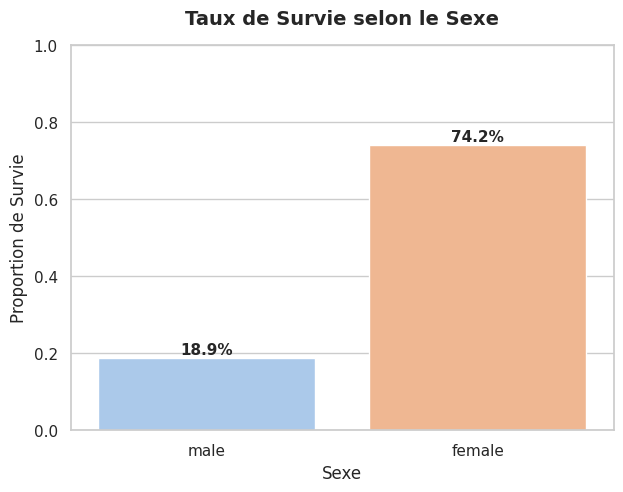

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, palette='pastel')

plt.title("Taux de Survie selon le Sexe", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Proportion de Survie", fontsize=12)
plt.ylim(0, 1)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.show()

> **Interprétation visuelle :** > Ce graphique en barres montre de manière flagrante l'écart de survie entre les genres. Les femmes ont un taux de survie massif de **74.2%**, alors que les hommes se situent à seulement **18.9%**. Visuellement, cela valide instantanément l'impact du protocole de sauvetage maritime axé sur la priorité accordée aux femmes.

Q3: Est-ce que la « classe sociale » et le prix du billet ont influencé les chances de survie ?

In [ ]:
# Taux de survie pour chaque classe de voyage
df.groupby('Pclass')['Survived'].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


/tmp/ipykernel_7387/1245744100.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='viridis')


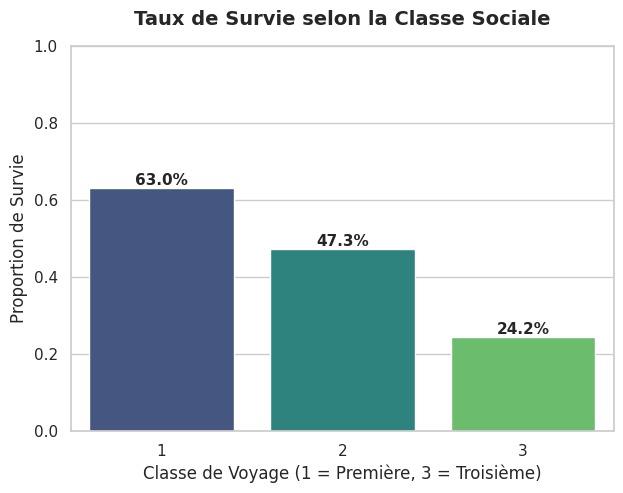

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='viridis')

plt.title("Taux de Survie selon la Classe Sociale", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Classe de Voyage (1 = Première, 3 = Troisième)", fontsize=12)
plt.ylabel("Proportion de Survie", fontsize=12)
plt.ylim(0, 1)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.show()

> **Interprétation visuelle :** > On observe une baisse linéaire et dramatique du taux de survie à mesure que l'on descend dans les classes sociales. Plus de **62%** des passagers de première classe ont été sauvés, contre seulement **24.2%** en troisième classe. Le graphique illustre parfaitement l'inégalité socio-économique face à l'accès aux canots de sauvetage.

Q4: Quel était l'âge moyen des survivants par rapport à ceux qui n'ont pas survécu ?

In [ ]:
# Âge moyen pour chaque catégorie (0 ou 1)
df.groupby('Survived')['Age'].mean()

,Age
Survived,
0,30.028233
1,28.291433


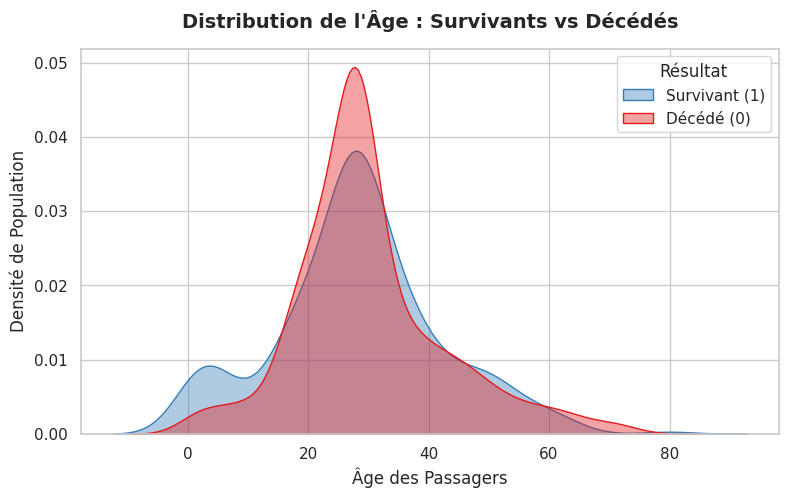

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
# رسم منحنى الكثافة الاحتمالية للأعمار
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False, palette='Set1', alpha=0.4)

plt.title("Distribution de l'Âge : Survivants vs Décédés", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Âge des Passagers", fontsize=12)
plt.ylabel("Densité de Population", fontsize=12)
plt.legend(title="Résultat", labels=["Survivant (1)", "Décédé (0)"])
plt.show()

> **Interprétation visuelle (Le piège de la moyenne) :** > Ce graphique de densité (KDE) montre pourquoi la "moyenne d'âge" était trompeuse. Regardez la courbe rouge (Survivants) entre **0 et 10 ans** : elle est nettement plus haute que la courbe bleue (Décédés), ce qui prouve graphiquement le sauvetage massif des enfants. Ensuite, les deux courbes se croisent et se superposent chez les adultes, expliquant pourquoi les âges moyens finaux restent si proches.

Q5: Était-il préférable de voyager seul ou en famille ?

In [ ]:
# Création d'une nouvelle colonne pour la taille de la famille
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Analyse du taux de survie selon la taille de la famille
df.groupby('FamilySize')['Survived'].mean() * 100

,Survived
FamilySize,
1,30.353818
2,55.279503
3,57.843137
4,72.413793
5,20.000000
6,13.636364
7,33.333333
8,0.000000
11,0.000000


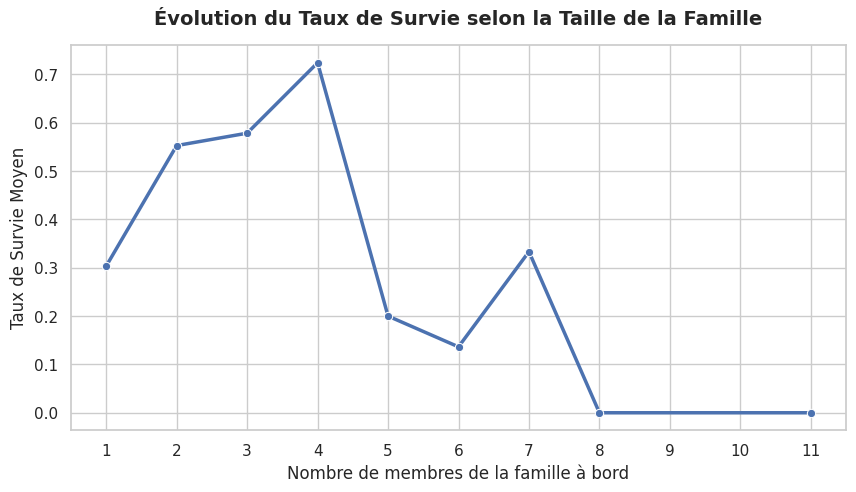

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x='FamilySize', y='Survived', data=df, errorbar=None, marker='o', linewidth=2.5, color='b')

plt.title("Évolution du Taux de Survie selon la Taille de la Famille", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Nombre de membres de la famille à bord", fontsize=12)
plt.ylabel("Taux de Survie Moyen", fontsize=12)
plt.xticks(range(1, 12)) # لإظهار جميع أحجام العائلات على المحور الأفقي
plt.show()

> **Interprétation visuelle :** > Ce graphique en ligne met en évidence une courbe en cloche. Le taux de survie augmente et culmine pour les familles de **2 à 4 personnes** (effet d'entraide familiale), puis s'effondre brutalement pour atteindre **0%** chez les familles très nombreuses (5 membres et plus). Visuellement, cela confirme la difficulté extrême à regrouper de grands groupes lors de la panique.


---

# 📊 Rapport d'Analyse des Données du Titanic

## 1. Taux Global de Survie : Une tragédie majeure

> **Résultat :** Décédés (`0`) : **61.62%** | Survivants (`1`) : **38.38%**

**Analyse :** Le naufrage du Titanic a été dévastateur. Moins de 4 passagers sur 10 (**38.38%**) ont survécu à la catastrophe. La grande majorité des personnes à bord (**61.62%**) a péri, ce qui montre le manque critique de canots de sauvetage et la soudaineté du drame.

---

## 2. Le Sexe : L'impact de la règle « Les femmes et les enfants d'abord »

> **Résultat (Taux de survie) :** Femmes (`female`) : **74.20%** | Hommes (`male`) : **18.89%**

**Analyse :** Le genre est le facteur de survie **le plus déterminant** de cette tragédie. Près de **75% des femmes ont été sauvées**, alors que **moins de 19% des hommes** ont survécu. Ce résultat confirme de manière flagrante que la règle chevaleresque *"Les femmes et les enfants d'abord"* a été strictement appliquée lors de l'évacuation.

---

## 3. La Classe Sociale : L'inégalité face à la mort

> **Résultat (Taux de survie) :** 1ère Classe : **62.96%** | 2ème Classe : **47.28%** | 3ème Classe : **24.24%**

**Analyse :** Il y avait une fracture sociale majeure sur le Titanic. Un passager de **première classe** avait près de **3 fois plus de chances de survivre** (62.96%) qu'un passager de troisième classe (24.24%). Les passagers de la classe populaire ont été désavantagés, probablement en raison de la position de leurs cabines (situées plus en profondeur dans le navire) et des difficultés d'accès aux ponts supérieurs.

---

## 4. L'Âge : Les limites de la moyenne et la réalité du sacrifice

### 📊 Résultats comparatifs (Âge moyen)

| État des données | Décédés (`0`) | Survivants (`1`) | Écart |
| :--- | :---: | :---: | :---: |
| **Avant traitement** (Données brutes) | 30.63 ans | 28.34 ans | 2.29 ans |
| **Après traitement** (Données nettoyées) | 30.03 ans | 28.29 ans | 1.74 ans |

---

### 🧠 Analyse approfondie

À première vue, l’écart entre l’âge moyen des survivants (~28 ans) et celui des disparus (~30 ans) est minime (moins de deux ans d'écart). Une interprétation hâtive pourrait conclure que l'âge n'a joué aucun rôle dans les chances de survie. C'est ici que réside **le « piège de la moyenne »** en statistique.

En réalité, cette apparente similitude cache une dynamique démographique binaire et profonde :

* **La priorité absolue aux enfants :** Le groupe des survivants intègre une proportion très élevée d'enfants en bas âge, sauvés au nom du protocole d'évacuation. Mathématiquement, la présence de ces très jeunes passagers fait baisser artificiellement la moyenne d'âge globale des survivants.
* **Le sacrifice des jeunes hommes :** À l'inverse, le groupe des décédés est massivement composé d'hommes adultes, jeunes et dans la force de l'âge (souvent issus de la classe ouvrière ou de l'équipage), qui ont cédé leur place ou sont restés bloqués à bord.

> 🔄 **L'impact du traitement des données :**
> Le fait que l'âge moyen des décédés baisse (passant de 30.63 à 30.03 ans) après le traitement des valeurs manquantes démontre que les passagers dont l'âge était inconnu étaient majoritairement des adultes jeunes. L'imputation (le remplacement des cases vides) a ainsi lissé les données, rapprochant les deux moyennes à seulement **1.74 an** d'écart.

---

## 5. La Taille de la Famille : Seul ou accompagné ?

> **Résultat (Taux de survie selon le nombre de personnes) :**
> * **1 personne** (Seul) : **30.35%**
> * **2 personnes** : **55.28%** | **3 personnes** : **57.84%** | **4 personnes** : **72.41%**
> * **5 personnes et plus** : Le taux chute drastiquement (**20%**, **13.6%**, puis **0%** pour les très grandes familles).
>
>

**Analyse :** Il existe une courbe en cloche très intéressante ici :

* **Voyager seul était un handicap :** Le taux de survie n'est que de 30.35%. Les personnes seules n'avaient personne pour s'entraider ou partager les alertes.
* **Avoir une petite famille était un avantage :** Les familles de 2 à 4 personnes affichent les meilleurs taux de survie (jusqu'à **72.41%** pour les familles de 4). Elles ont pu s'organiser et se regrouper rapidement.
* **Les familles nombreuses ont été piégées :** Dès que la famille dépassait 5 personnes, le taux de survie s'effondrait (0% de survie pour les familles de 8 et 11 personnes). Il était probablement impossible de retrouver et de regrouper tous les membres de la famille au milieu de la panique et de l'obscurité.

---

## 📌 Conclusion Synthétique

Si l'on devait dresser le profil type des personnes à bord :

* **Le survivant idéal :** Une femme voyageant en 1ère classe, accompagnée de 1 à 3 membres de sa famille.
* **Le profil le plus vulnérable :** Un homme, voyageant seul ou au sein d'une famille très nombreuse, en 3ème classe.